## 1️⃣ Imports
We import necessary libraries for data processing, cleaning, and manipulation.


In [ ]:

import pandas as pd
import numpy as np
import re


## 2️⃣ Load Dataset
Load the dataset containing emails with their subjects, body, and priority.


In [ ]:
import pandas as pd

df = pd.read_csv("../data/sample_emails_with_triage_200.csv")
print(df.head(80))


    id                sender                      subject  \
0    1       alerts@bank.com       Password Reset Request   
1    2       alerts@bank.com  Congratulations! You've Won   
2    3  no-reply@service.com          Promotion: Big Sale   
3    4        sales@shop.com               Monthly Report   
4    5  no-reply@service.com                       Survey   
5    6       alerts@bank.com        Unusual Login Attempt   
6    7        hr@company.com               Project Update   
7    8        sales@shop.com               Project Update   
8    9     security@bank.com            Account Suspended   
9   10      boss@company.com               Monthly Report   
10  11     support@cloud.com                       Survey   
11  12     news@techblog.com                Policy Update   
12  13  teamlead@company.com         Subscription Renewal   
13  14       alerts@bank.com                       Survey   
14  15     security@bank.com               Security Alert   
15  16     news@techblog

## 3️⃣ Clean Email Text
Clean the email text by:
- Converting to lowercase
- Removing special characters
- Removing extra spaces


In [ ]:
import re

def clean_text(text):
    if pd.isna(text):      
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', ' ', text)  
    text = re.sub(r'\s+', ' ', text)           
    return text.strip()

df["clean_subject"] = df["subject"].apply(clean_text)
df["clean_body"] = df["body"].apply(clean_text)

df["clean_text"] = df["clean_subject"] + " " + df["clean_body"]

df.head()


,id,sender,subject,body,priority,triage_label,clean_subject,clean_body,clean_text
0,1,alerts@bank.com,Password Reset Request,Reminder: The client meeting is scheduled at 1...,low,notify_human,password reset request,reminder the client meeting is scheduled at 10...,password reset request reminder the client mee...
1,2,alerts@bank.com,Congratulations! You've Won,Your invoice of INR 25515.09 is due on 2025-12...,low,respond,congratulations you ve won,your invoice of inr 25515 09 is due on 2025 12...,congratulations you ve won your invoice of inr...
2,3,no-reply@service.com,Promotion: Big Sale,Reminder: The client meeting is scheduled at 1...,low,ignore,promotion big sale,reminder the client meeting is scheduled at 11...,promotion big sale reminder the client meeting...
3,4,sales@shop.com,Monthly Report,"Hello team, please find the attached weekly re...",medium,respond,monthly report,hello team please find the attached weekly rep...,monthly report hello team please find the atta...
4,5,no-reply@service.com,Survey,"Hello team, please find the attached weekly re...",low,respond,survey,hello team please find the attached weekly rep...,survey hello team please find the attached wee...


## 4️⃣ Define Rule-Based Triage Function
Assign emails into categories based on keywords:
- `ignore` → spam/promotions
- `notify_human` → requires human attention
- `respond_or_act` → can be handled automatically


In [ ]:
def triage_rule(text):
    text = text.lower()

    
    spam_keywords = ["win", "free", "lottery", "promotion", "offer", "sale"]
    
    
    human_keywords = ["complaint", "issue", "problem", "urgent", "resume", "cv"]
    
    
    auto_keywords = ["update", "status", "confirm", "request", "invoice", "details"]

    if any(word in text for word in spam_keywords):
        return "ignore"
    if any(word in text for word in human_keywords):
        return "notify_human"
    if any(word in text for word in auto_keywords):
        return "respond_or_act"


    return "notify_human"



## 5️⃣ Apply Triage Rule
Apply the function to the cleaned text to assign each email a triage label.


In [31]:
df["triage_output"] = df["clean_text"].apply(triage_rule)
df[["clean_text","triage_output"]].head()


,clean_text,triage_output
0,password reset request reminder the client mee...,respond_or_act
1,congratulations you ve won your invoice of inr...,respond_or_act
2,promotion big sale reminder the client meeting...,ignore
3,monthly report hello team please find the atta...,notify_human
4,survey hello team please find the attached wee...,notify_human


In [20]:
import matplotlib.pyplot as plt


## 6️⃣ Visual Summary
Count the number of emails in each triage category and display a bar chart.


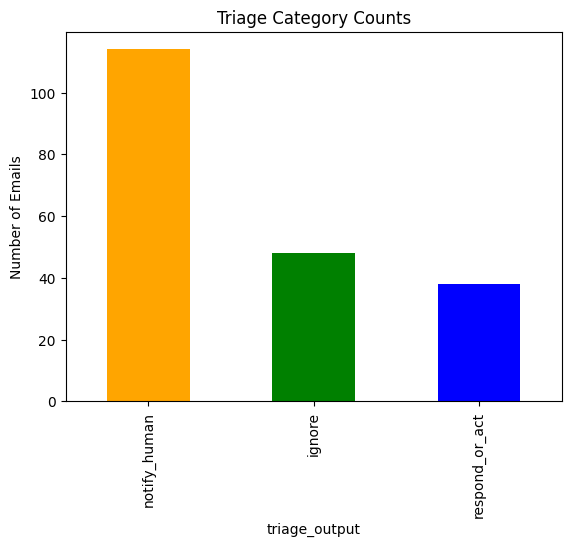

In [21]:
df['triage_output'].value_counts().plot(
    kind='bar', 
    color=['orange','green','blue'], 
    title="Triage Category Counts"
)
plt.ylabel("Number of Emails")
plt.show()


## 7️⃣ Save Cleaned and Triaged Data
Save the processed dataset to a CSV file for submission.


In [10]:
df.to_csv("../data/milestone1_shwetha.csv", index=False)
print("Saved as milestone1_shwetha.csv")


Saved as milestone1_shwetha.csv


In [28]:
accuracy = (df['triage_label'] == df['triage_output']).mean()
print("Accuracy:", accuracy)


Accuracy: 0.515
